In [1]:
import torch
from UNet import UNet
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from utils import threshold, viola_jones
import cv2
import numpy as np

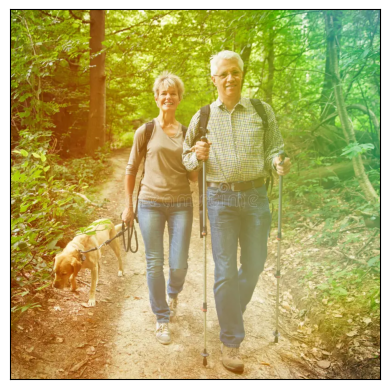

In [2]:
img_path = 'sample.jpg'

t=0.6 #Threshold
sample = Image.open(img_path)
# sample = cv2.resize(sample, (608,408))
plt.xticks([])
plt.yticks([])
plt.imshow(sample)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt_path = 'checkpoints/final_model.pth'

state_dict = torch.load(ckpt_path, weights_only=False)
model = UNet(in_channels=3, out_channels=1)
model = torch.nn.DataParallel(model) #Weights Stored in DataParallel format
model.load_state_dict(state_dict)
model.to(device)
model.eval()
model = model.module 

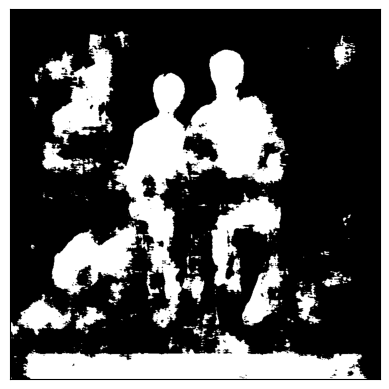

In [4]:
transform = transforms.ToTensor()
tensor_image = transform(sample).cuda()
output = model(tensor_image[None]).detach().cpu().numpy()

thresh_map = threshold(output[0][0], t)
plt.xticks([])
plt.yticks([])
plt.imshow(thresh_map, cmap='gray')

In [5]:
imgs, bboxs = viola_jones(sample)

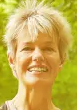

In [26]:
imgs[0]

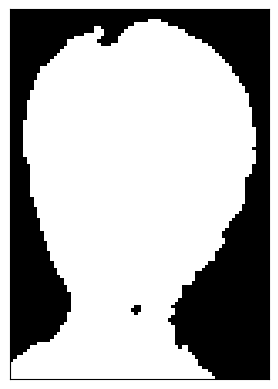

In [ ]:
x,w,y,h = bboxs[0]

plt.xticks([])
plt.yticks([])
plt.imshow(thresh_map[y:y+h, x:x+w], cmap='gray')

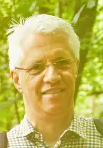

In [27]:
imgs[1]

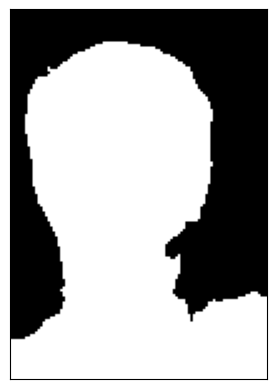

In [24]:
x,w,y,h = bboxs[1]
imgs[1]
plt.xticks([])
plt.yticks([])
plt.imshow(thresh_map[y:y+h, x:x+w], cmap='gray')